# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan dalam proyek ini merupakan Dataset Gaming vs Academic Performance yang bersumber dari kaggle:

   https://www.kaggle.com/datasets/aiexplorer77/gaming-vs-academic-performance

2. **Deskripsi Dataset**:
   Dataset ini mengeksplorasi pengaruh kebiasaan bermain game terhadap performa akademik siswa. Dataset ini mencakup berbagai variabel gaya hidup seperti jam bermain game, jam belajar, waktu tidur, dan tingkat kehadiran untuk melihat korelasinya dengan nilai akademik.

   **Informasi Fitur**:
   
   - **age**: Usia mahasiswa.
   - **gender**: Jenis kelamin.
   - **gaming_hours**: Rata-rata jumlah jam yang digunakan siswa untuk bermain game per hari.
   - **study_hours**: Rata-rata jumlah jam yang digunakan siswa untuk belajar per hari.
   - **sleep_hours**: Rata-rata jumlah jam tidur siswa per hari.
   - **attendance**: Persentase kehadiran siswa di kelas.
   - **gaming_genre**: Genre/Tipe Game yang yang disukai dan sering dimainkan siswa.
   - **social_activity**: Waktu yang di gunakan siswa untuk melakukan interaksi sosial per harinya.
   - **device_usage**: Jumlah total screen time (Penggunaan device) termasuk bermain game dan penggunaan lainnya (Sosmed dll).
   - **reaction_time_ms**: Performa Reaksi kognitif siswa dalam milisecond (nilai lebih rendah berarti performa yang lebih baik).
   - **addiction_score**: Estimasi nilai adiksi bermain game dari pola waktu bermain game dan penggunaan device.
   - **stress_level**: Tingkat stres level siswa.
   - **grades**: Nilai Akademik siswa.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Memuat dataset
df = pd.read_csv('../Gaming_Academic_Performance.csv')

df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [4]:
df = df.drop(columns=['student_id'])

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

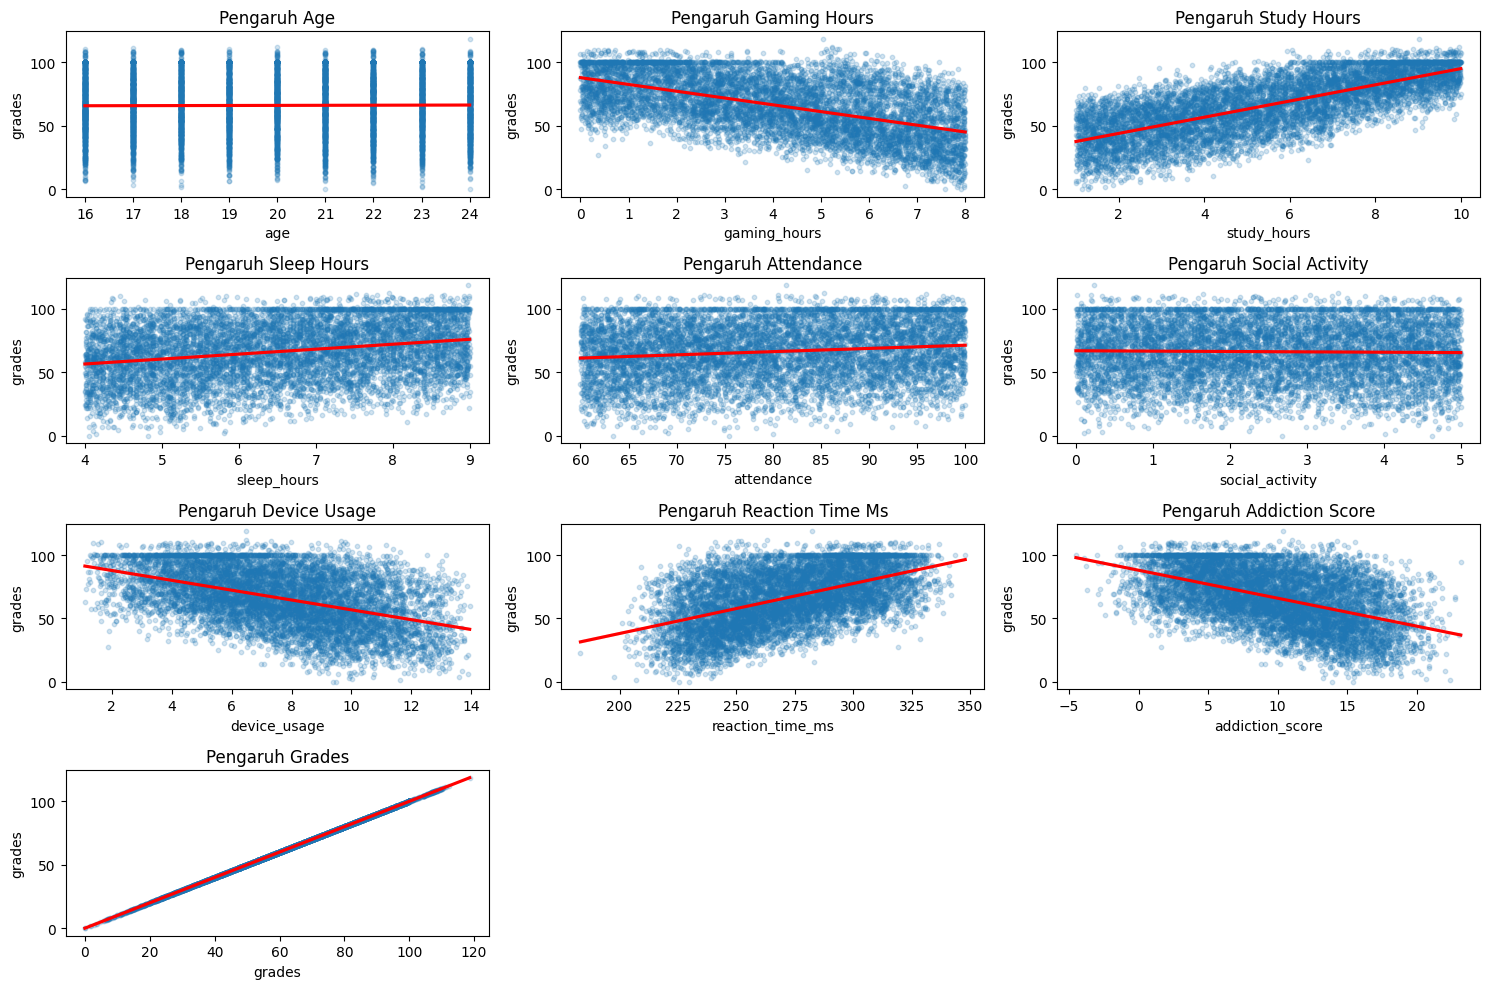

In [5]:
# Analisis distribusi variabel numerik dengan statistik deskriptif
num_vars = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars, 1):
    plt.subplot(4, 3, i)
    # Menampilkan scatter plot dengan garis tren (regression line)
    sns.regplot(data=df, x=col, y='grades',
                scatter_kws={'alpha':0.2, 's':10},
                line_kws={'color':'red'})
    plt.title(f'Pengaruh {col.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

C:\Users\feryg\AppData\Local\Temp\ipykernel_16880\3752295690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stress_level', y='grades',


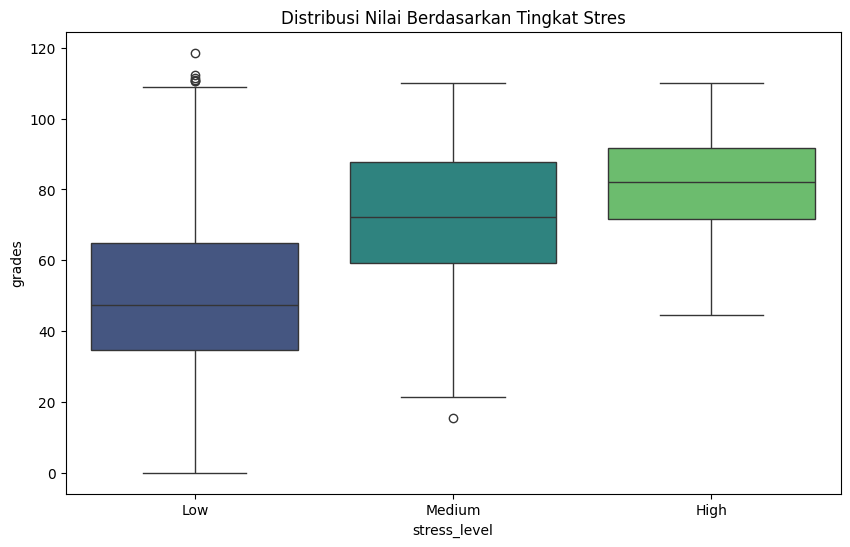

In [6]:
# Visualisasi kaitan Tingkat Stres dengan Nilai
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='stress_level', y='grades',
            order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Distribusi Nilai Berdasarkan Tingkat Stres')
plt.show()

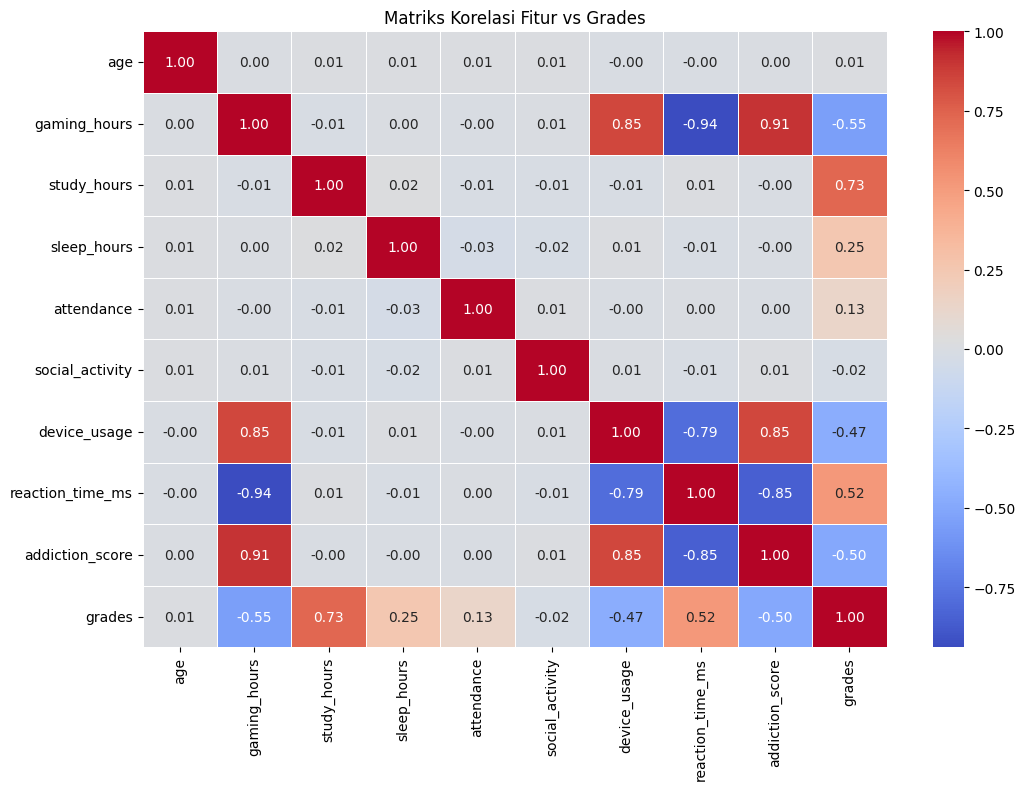

In [7]:
# Periksa hubungan antara variabel menggunakan matriks korelasi
plt.figure(figsize=(12, 8))
corr_matrix = df[num_vars].corr()

# Menampilkan heatmap korelasi
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur vs Grades')
plt.show()

In [8]:
# Analisis distribusi variabel kategorikal dengan statistik deskriptif
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variabel kategorikal yang ditemukan: {cat_vars}")

Variabel kategorikal yang ditemukan: ['gender', 'gaming_genre', 'stress_level']


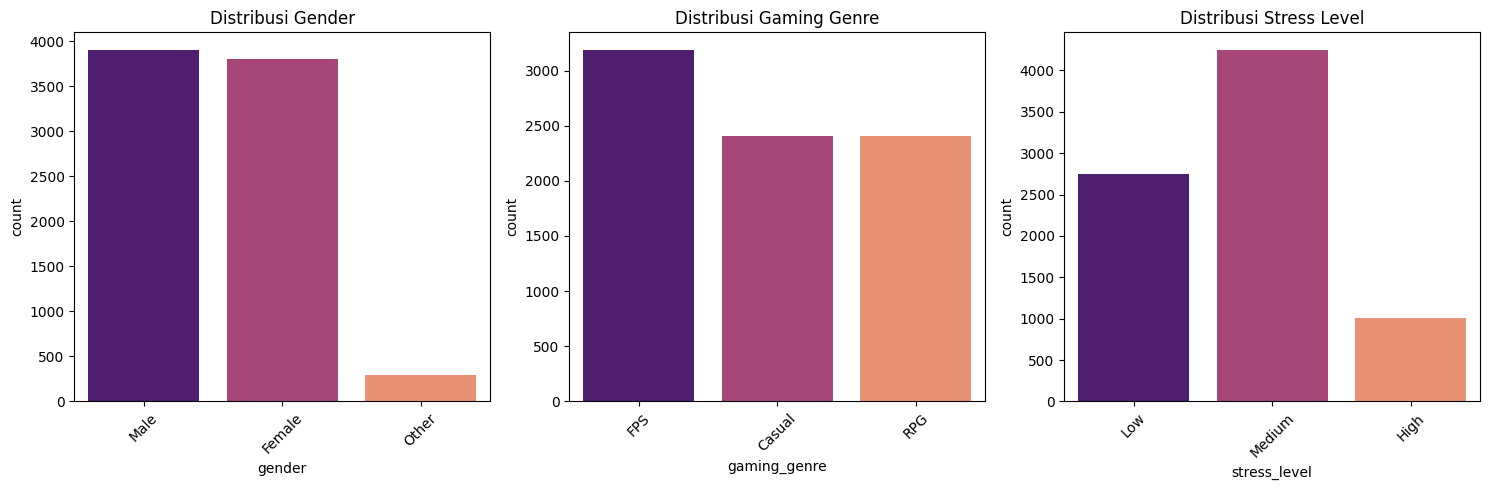

In [9]:
# Memvisualisasikan variabel kategorikal dengan bar chart
plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_vars, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col, palette='magma', hue=col, legend=False)
    plt.title(f'Distribusi {col.replace("_", " ").title()}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

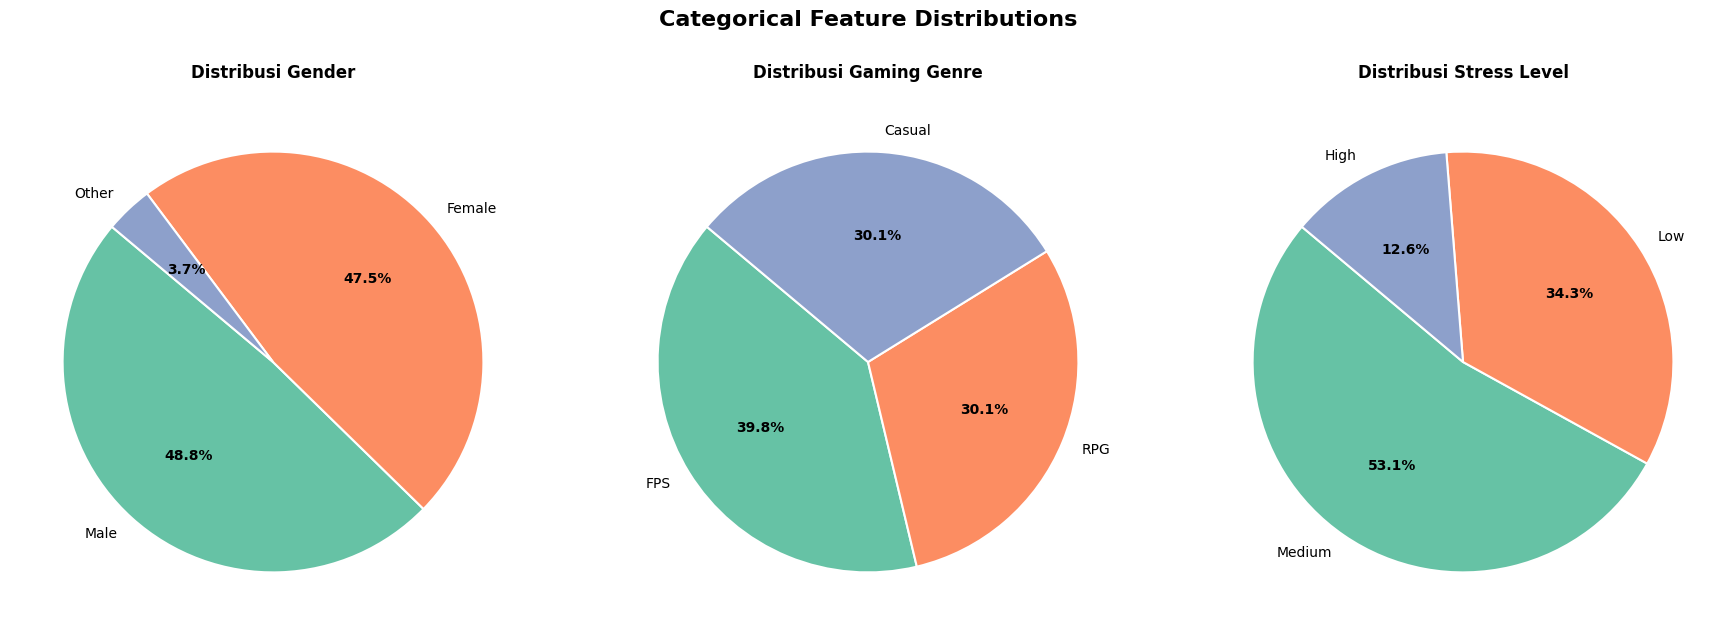

In [10]:
# Memvisualisasikan variabel kategorikal dengan pie chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Loop untuk membuat pie chart di setiap subplot
for ax, col in zip(axes, cat_vars):
    # Hitung distribusi frekuensi
    counts = df[col].value_counts()

    # Pilih palette warna
    colors = sns.color_palette('Set2', len(counts))

    # Buat pie chart
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )

    # Styling teks persentase
    for at in autotexts:
        at.set_fontsize(10)
        at.set_weight('bold')

    ax.set_title(f'Distribusi {col.replace("_", " ").title()}', weight='bold', pad=15)

plt.suptitle('Categorical Feature Distributions', fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
# Menghapus atau Menangani Data kosong

# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [12]:
# Mencari data duplikat
duplicates = df[df.duplicated(keep=False)]
print("Duplicate Rows:")
print(duplicates)

# Menghapus data duplikat jika ada
df.drop_duplicates(inplace=True)

Duplicate Rows:
Empty DataFrame
Columns: [age, gender, gaming_hours, study_hours, sleep_hours, attendance, gaming_genre, social_activity, device_usage, reaction_time_ms, addiction_score, stress_level, grades]
Index: []


In [13]:
# Menangani sisa data yang hilang dengan SimpleImputer
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_vars] = num_imputer.fit_transform(df[num_vars])

df[cat_vars] = cat_imputer.fit_transform(df[cat_vars])

print("Imputasi selesai. Tidak ada lagi nilai yang hilang.")

Imputasi selesai. Tidak ada lagi nilai yang hilang.


In [14]:
# Mengidentifikasi Outlier pada data

for feature in num_vars:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Memfilter dataframe df agar hanya menyimpan data di dalam bound
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

In [15]:
print("Informasi Data:")
print(df.info())

Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               8000 non-null   float64
 1   gender            8000 non-null   object 
 2   gaming_hours      8000 non-null   float64
 3   study_hours       8000 non-null   float64
 4   sleep_hours       8000 non-null   float64
 5   attendance        8000 non-null   float64
 6   gaming_genre      8000 non-null   object 
 7   social_activity   8000 non-null   float64
 8   device_usage      8000 non-null   float64
 9   reaction_time_ms  8000 non-null   float64
 10  addiction_score   8000 non-null   float64
 11  stress_level      8000 non-null   object 
 12  grades            8000 non-null   float64
dtypes: float64(10), object(3)
memory usage: 812.6+ KB
None


In [16]:
# Normalisasi fitur numerik
scaler = StandardScaler()

num_features = [col for col in num_vars if col != 'grades']
df[num_features] = scaler.fit_transform(df[num_features])

In [17]:
# Encoding Data Kategorikal
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_data = encoder.fit_transform(df[cat_vars])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_vars),
    index=df.index
)

In [18]:
# Menggabunggan kembali dataset
df_final = pd.concat([df.drop(columns=cat_vars), encoded_df], axis=1)

In [19]:
df_final

,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades,gender_Female,gender_Male,gender_Other,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG,stress_level_High,stress_level_Low,stress_level_Medium
0,0.779453,1.361929,1.288781,0.323415,0.997736,0.515052,0.654529,-1.197936,0.949555,86.459555,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.380232,-1.739441,1.265486,0.787865,-1.403882,-1.032443,-1.614956,1.956741,-1.477204,98.230000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.166014,-1.020408,1.591620,-1.451201,0.291327,0.660781,-0.747755,1.443813,-1.028392,90.560000,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.006330,1.097707,-1.467830,0.926507,-0.418536,-0.727108,1.547562,-0.994124,0.919767,32.670000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.779453,0.551935,0.143429,-0.654010,-1.236347,-1.039383,0.237534,-0.740377,0.510673,58.710000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,1.552576,0.972092,-0.143880,-1.153121,-1.394383,1.111844,0.875942,-1.351135,0.244564,35.110000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7996,0.779453,0.729527,0.244375,-0.182628,0.387184,0.633023,1.329839,-0.576648,0.149241,60.800000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7997,0.006330,-0.526615,1.183952,1.474143,-1.086948,-0.102558,-0.437776,1.151342,-0.692777,90.280000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
7998,0.779453,-1.345273,-0.959216,0.552174,-1.619777,-0.338499,-1.113086,1.842945,-1.542738,56.330000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [20]:
X = df_final.drop('grades', axis=1)
y = df_final['grades']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)